In [1]:
# !pip install scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('House_Rent_Dataset.csv')

In [4]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 887.8 KB


In [6]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [7]:
df.isna().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [8]:
print('Total numbers of missing values:', df.isna().sum().sum())

Total numbers of missing values: 0


<Axes: xlabel='Tenant Preferred', ylabel='count'>

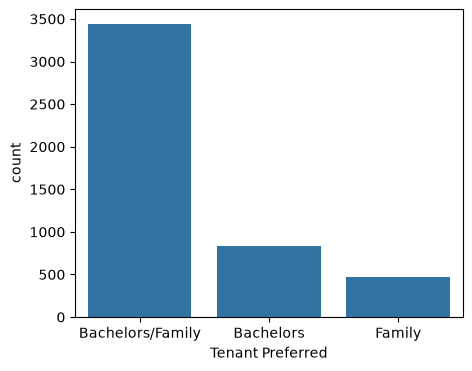

In [9]:
# Univariate EDA
plt.figure(figsize = (5, 4))
sns.countplot(data = df, x = 'Tenant Preferred')

In [10]:
df_house = df.drop(columns = 'Posted On')

In [11]:
df_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   BHK                4746 non-null   int64
 1   Rent               4746 non-null   int64
 2   Size               4746 non-null   int64
 3   Floor              4746 non-null   str  
 4   Area Type          4746 non-null   str  
 5   Area Locality      4746 non-null   str  
 6   City               4746 non-null   str  
 7   Furnishing Status  4746 non-null   str  
 8   Tenant Preferred   4746 non-null   str  
 9   Bathroom           4746 non-null   int64
 10  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(7)
memory usage: 804.4 KB


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [13]:
df_house.columns

Index(['BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom',
       'Point of Contact'],
      dtype='str')

In [14]:
names = [
    column for column in df_house.columns
    if pd.api.types.is_string_dtype(df_house[column])
]

names

['Floor',
 'Area Type',
 'Area Locality',
 'City',
 'Furnishing Status',
 'Tenant Preferred',
 'Point of Contact']

In [15]:
df_strings = df_house[names]

In [16]:
df_strings.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Floor              4746 non-null   str  
 1   Area Type          4746 non-null   str  
 2   Area Locality      4746 non-null   str  
 3   City               4746 non-null   str  
 4   Furnishing Status  4746 non-null   str  
 5   Tenant Preferred   4746 non-null   str  
 6   Point of Contact   4746 non-null   str  
dtypes: str(7)
memory usage: 656.1 KB


In [17]:
def encoder(col):
    df_house[col] = le.fit_transform(df_strings[col])

In [18]:
for i in names:
    encoder(i)

In [19]:
df_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   BHK                4746 non-null   int64
 1   Rent               4746 non-null   int64
 2   Size               4746 non-null   int64
 3   Floor              4746 non-null   int64
 4   Area Type          4746 non-null   int64
 5   Area Locality      4746 non-null   int64
 6   City               4746 non-null   int64
 7   Furnishing Status  4746 non-null   int64
 8   Tenant Preferred   4746 non-null   int64
 9   Bathroom           4746 non-null   int64
 10  Point of Contact   4746 non-null   int64
dtypes: int64(11)
memory usage: 408.0 KB


<Axes: >

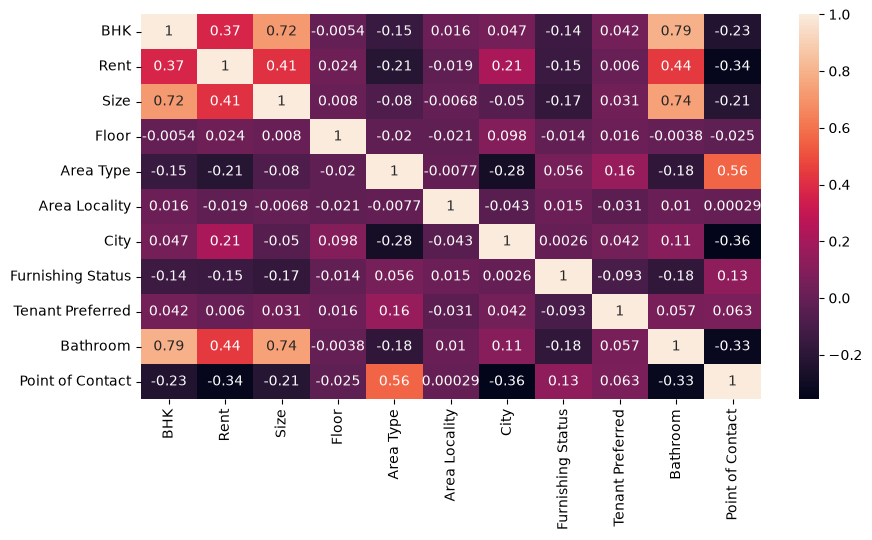

In [20]:
plt.figure(figsize = (10, 5))
sns.heatmap(df_house.corr(), annot = True)

In [21]:
x = df_house[['BHK', 'Size', 'Floor', 'Area Type', 
               'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']]

In [22]:
y = df_house['Rent']

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [24]:
print('Total training rows:', x_train.shape[0])
print('Total training columns:', x_train.shape[1])
print('Total training:', y_train.shape[0])
print(x_test.shape)
print(y_test.shape)

Total training rows: 3796
Total training columns: 10
Total training: 3796
(950, 10)
(950,)


In [25]:
model = LinearRegression()

In [26]:
import warnings
warnings.filterwarnings('ignore')
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 489.96, 25.39, -1.38,..., 226.65, 17409.94,-11496.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['BHK','Size','Floor',...,'Tenant Preferred','Bathroom','Point of Contact']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9440
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [27]:
pred = model.predict(x_test)

In [28]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, pred)
print('MAE: ', round(mae , 2))

MAE:  26687.34


In [29]:
print('Maximum Rent:', max(df_house['Rent']))
print('Minimum Rent:', min(df_house['Rent']))
print('Average Rent:', np.mean(df_house['Rent']))

Maximum Rent: 3500000
Minimum Rent: 1200
Average Rent: 34993.45132743363


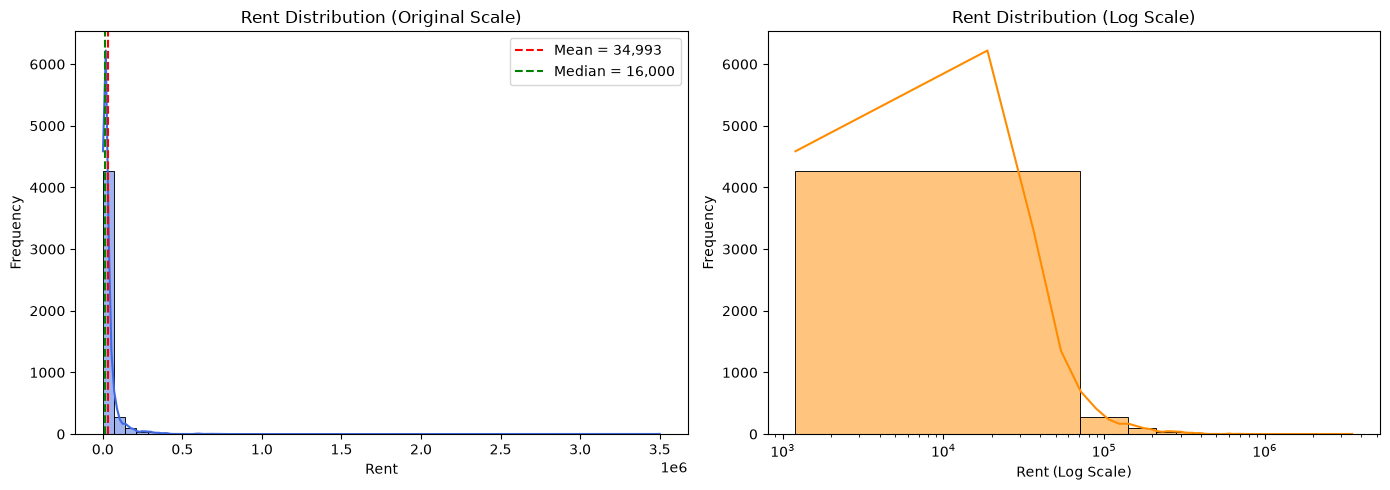

Minimum Rent: 1200
Maximum Rent: 3500000
Average Rent: 34993.45
Median Rent: 16000.0
Rent Skewness: 21.41
Result: Rent distribution is highly right-skewed.
Expensive properties and outliers can affect Linear Regression.


In [30]:
# Rent Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original scale
sns.histplot(df['Rent'], bins=50, kde=True, ax=axes[0], color='royalblue')

axes[0].axvline(
    df['Rent'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['Rent'].mean():,.0f}"
)

axes[0].axvline(
    df['Rent'].median(),
    color='green',
    linestyle='--',
    label=f"Median = {df['Rent'].median():,.0f}"
)

axes[0].set_title('Rent Distribution (Original Scale)')
axes[0].set_xlabel('Rent')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Log scale
sns.histplot(df['Rent'], bins=50, kde=True, ax=axes[1], color='darkorange')
axes[1].set_xscale('log')
axes[1].set_title('Rent Distribution (Log Scale)')
axes[1].set_xlabel('Rent (Log Scale)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

rent_skewness = df['Rent'].skew()

print("Minimum Rent:", df['Rent'].min())
print("Maximum Rent:", df['Rent'].max())
print("Average Rent:", round(df['Rent'].mean(), 2))
print("Median Rent:", round(df['Rent'].median(), 2))
print("Rent Skewness:", round(rent_skewness, 2))

if abs(rent_skewness) > 1:
    print("Result: Rent distribution is highly right-skewed.")
    print("Expensive properties and outliers can affect Linear Regression.")
else:
    print("Result: Rent distribution is not highly skewed.")

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression metrics
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

average_test_rent = y_test.mean()
mae_percentage = (mae / average_test_rent) * 100

print("REGRESSION MODEL METRICS")
print("-" * 40)
print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Average Test Rent: {average_test_rent:,.2f}")
print(f"MAE as Percentage of Average Rent: {mae_percentage:.2f}%")

REGRESSION MODEL METRICS
----------------------------------------
MAE: 26,687.34
MSE: 14,615,659,167.39
RMSE: 120,895.24
R² Score: 0.1070
Average Test Rent: 36,837.12
MAE as Percentage of Average Rent: 72.45%


In [32]:
from sklearn.dummy import DummyRegressor

# Baseline always predicts the median training rent
baseline_model = DummyRegressor(strategy='median')

baseline_model.fit(x_train, y_train)

baseline_pred = baseline_model.predict(x_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)

improvement_percentage = (
    (baseline_mae - mae) / baseline_mae
) * 100

print("BASELINE COMPARISON")
print("-" * 40)
print(f"Linear Regression MAE: {mae:,.2f}")
print(f"Baseline Model MAE: {baseline_mae:,.2f}")
print(f"Improvement Over Baseline: {improvement_percentage:.2f}%")

if mae < baseline_mae:
    print("Result: Linear Regression performs better than the baseline.")
else:
    print("Result: Linear Regression does not perform better than the baseline.")

BASELINE COMPARISON
----------------------------------------
Linear Regression MAE: 26,687.34
Baseline Model MAE: 26,912.14
Improvement Over Baseline: 0.84%
Result: Linear Regression performs better than the baseline.


In [33]:
metrics_table = pd.DataFrame({
    'Metric': [
        'MAE',
        'MSE',
        'RMSE',
        'R² Score',
        'Baseline MAE',
        'Improvement Over Baseline (%)'
    ],
    
    'Value': [
        mae,
        mse,
        rmse,
        r2,
        baseline_mae,
        improvement_percentage
    ]
})

metrics_table.round(2)

,Metric,Value
0,MAE,2.668734e+04
1,MSE,1.461566e+10
2,RMSE,1.208952e+05
3,R² Score,1.100000e-01
4,Baseline MAE,2.691214e+04
5,Improvement Over Baseline (%),8.400000e-01


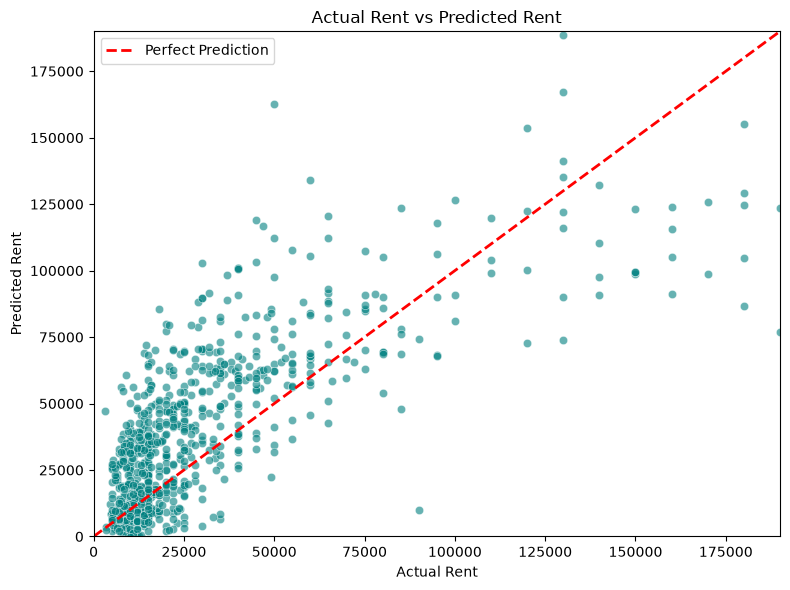

In [34]:
# Limit graph to 99th percentile so outliers do not hide the main pattern
plot_limit = np.percentile(
    np.concatenate([np.asarray(y_test), pred]),
    99
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=pred,
    alpha=0.6,
    color='teal'
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlim(0, plot_limit)
plt.ylim(0, plot_limit)

plt.title('Actual Rent vs Predicted Rent')
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.legend()
plt.tight_layout()
plt.show()

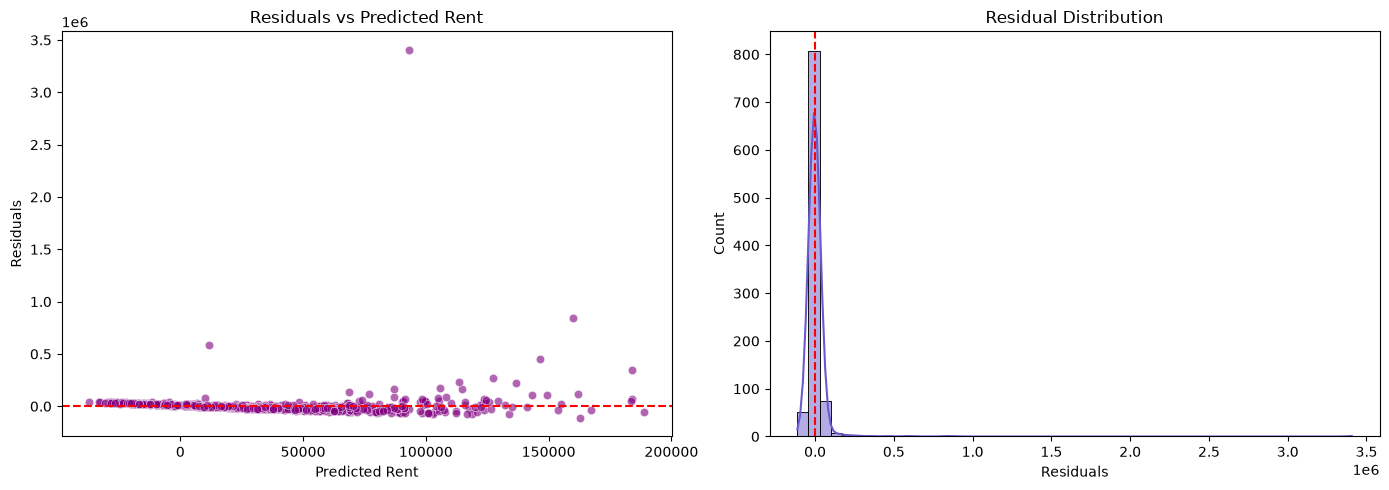

In [35]:
# Residual = Actual Rent - Predicted Rent
residuals = np.asarray(y_test) - pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual scatter plot
sns.scatterplot(
    x=pred,
    y=residuals,
    alpha=0.6,
    color='purple',
    ax=axes[0]
)

axes[0].axhline(
    y=0,
    color='red',
    linestyle='--'
)

axes[0].set_title('Residuals vs Predicted Rent')
axes[0].set_xlabel('Predicted Rent')
axes[0].set_ylabel('Residuals')

# Residual distribution
sns.histplot(
    residuals,
    bins=50,
    kde=True,
    color='slateblue',
    ax=axes[1]
)

axes[1].axvline(
    x=0,
    color='red',
    linestyle='--'
)

axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

In [36]:
print("=" * 60)
print("FINAL REGRESSION MODEL RESULT")
print("=" * 60)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Baseline MAE: {baseline_mae:,.2f}")
print(f"Improvement Over Baseline: {improvement_percentage:.2f}%")
print(f"MAE Percentage: {mae_percentage:.2f}%")

# Automatic model verdict
if r2 >= 0.70 and mae < baseline_mae:
    
    verdict = "GOOD MODEL"
    
    reason = (
        "The model explains at least 70% of the variation "
        "and performs better than the baseline model."
    )

elif r2 >= 0.50 and mae < baseline_mae:
    
    verdict = "ACCEPTABLE, BUT NEEDS IMPROVEMENT"
    
    reason = (
        "The model has moderate predictive performance "
        "and performs better than the baseline."
    )

else:
    
    verdict = "MODEL IS NOT GOOD ENOUGH"
    
    reason = (
        "The model has a low R² score, high prediction error, "
        "or does not perform better than the baseline."
    )

print("\nFinal Verdict:", verdict)
print("Reason:", reason)

if abs(rent_skewness) > 1:
    print(
        "\nRent is highly right-skewed. Extreme rent values "
        "may be reducing the performance of Linear Regression."
    )

print(
    "\nSuggested improvements: log transformation of Rent, "
    "one-hot encoding, outlier treatment, Random Forest "
    "and Gradient Boosting."
)

FINAL REGRESSION MODEL RESULT
MAE: 26,687.34
RMSE: 120,895.24
R² Score: 0.1070
Baseline MAE: 26,912.14
Improvement Over Baseline: 0.84%
MAE Percentage: 72.45%

Final Verdict: MODEL IS NOT GOOD ENOUGH
Reason: The model has a low R² score, high prediction error, or does not perform better than the baseline.

Rent is highly right-skewed. Extreme rent values may be reducing the performance of Linear Regression.

Suggested improvements: log transformation of Rent, one-hot encoding, outlier treatment, Random Forest and Gradient Boosting.


In [37]:
deployment_df = df.drop(columns=["Posted On"]).copy()

deployment_df.head()

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [38]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = [
    "Floor",
    "Area Type",
    "Area Locality",
    "City",
    "Furnishing Status",
    "Tenant Preferred",
    "Point of Contact"
]

label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()

    deployment_df[column] = encoder.fit_transform(
        deployment_df[column].astype(str)
    )

    label_encoders[column] = encoder

print("Label Encoders created successfully")
print(label_encoders.keys())

Label Encoders created successfully
dict_keys(['Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact'])


In [39]:
feature_columns = [
    "BHK",
    "Size",
    "Floor",
    "Area Type",
    "Area Locality",
    "City",
    "Furnishing Status",
    "Tenant Preferred",
    "Bathroom",
    "Point of Contact"
]

X_deployment = deployment_df[feature_columns]
y_deployment = deployment_df["Rent"]

X_deployment.head()

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,1100,455,2,221,4,2,1,2,2
1,2,800,14,2,1527,4,1,1,1,2
2,2,1000,14,2,1760,4,1,1,1,2
3,2,800,10,2,526,4,2,1,1,2
4,2,850,10,1,1890,4,2,0,1,2


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train_deploy, X_test_deploy, y_train_deploy, y_test_deploy = (
    train_test_split(
        X_deployment,
        y_deployment,
        test_size=0.2,
        random_state=42
    )
)

deployment_model = LinearRegression()

deployment_model.fit(
    X_train_deploy,
    y_train_deploy
)

print("Deployment model successfully trained")

Deployment model successfully trained


In [41]:
from sklearn.metrics import mean_absolute_error, r2_score

deployment_predictions = deployment_model.predict(
    X_test_deploy
)

mae = mean_absolute_error(
    y_test_deploy,
    deployment_predictions
)

r2 = r2_score(
    y_test_deploy,
    deployment_predictions
)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 23404.195401971636
R² Score: 0.45934491524690857


In [43]:
import joblib

joblib.dump(
    deployment_model,
    "rent_model.pkl"
)

joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)

joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)

print("All files saved successfully")

All files saved successfully


In [44]:
saved_model = joblib.load("rent_model.pkl")
saved_encoders = joblib.load("label_encoders.pkl")
saved_columns = joblib.load("feature_columns.pkl")

print("Saved model:", saved_model)
print("Saved encoders:", saved_encoders.keys())
print("Saved columns:", saved_columns)

Saved model: LinearRegression()
Saved encoders: dict_keys(['Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact'])
Saved columns: ['BHK', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']
